<a href="https://colab.research.google.com/github/SebastianJaramilloo/cloud-lab3/blob/main/Laboratorio_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<table style="border: none; border-collapse: collapse;">
    <tr>
        <td style="width: 20%; vertical-align: middle; padding-right: 10px;">
            <img src="https://i.imgur.com/nt7hloA.png" width="100">
        </td>
        <td style="width: 2px; text-align: center;">
            <font color="#0030A1" size="7">|</font><br>
            <font color="#0030A1" size="7">|</font>
        </td>
        <td>
            <p style="font-variant: small-caps;"><font color="#0030A1" size="5">
                <b>Facultad de Ciencias Exactas, Naturales y Ambientales</b>
            </font> </p>
            <p style="font-variant: small-caps;"><font color="#0030A1" size="4">
                Computación Paralela, Distribuida y en la Nube. &bull; Laboratorio IV
            </font></p>
            <p style="font-style: oblique;"><font color="#0030A1" size="3">
                David Jaramillo y Sebastián Quijia &bull; 31-05-2026
            </font></p>
        </td>  
    </tr>
</table>

# Parte I. Implementación de Algoritmos Paralelos

## Actividad 1.1 – Búsqueda Paralela en Arreglos Grandes

### Descripción

La búsqueda secuencial en grandes volúmenes de datos puede ser ineficiente porque revisa los elementos uno por uno. En esta actividad se implementa una búsqueda paralela dividiendo el arreglo en bloques y ejecutando la búsqueda simultáneamente usando varios hilos.

El objetivo es comparar el tiempo de ejecución de la versión secuencial frente a versiones paralelas con 2, 4 y 8 hilos.

### Objetivos

- Entender el paralelismo de datos.
- Medir el speedup real.
- Identificar limitaciones del paralelismo.

In [12]:
from concurrent.futures import ThreadPoolExecutor
import time
import random


# ================= CONFIGURACIÓN =================

N = 10_000_000
datos = [random.randint(1, 1000) for _ in range(N)]
objetivo = random.choice(datos)

# ================= BÚSQUEDA POR BLOQUE =================

def buscar_bloque(datos, objetivo, inicio, fin):
    for i in range(inicio, fin):
        if datos[i] == objetivo:
            return i
    return -1

# ================= VERSIÓN SECUENCIAL =================

def busqueda_secuencial(datos, objetivo):
    for i in range(len(datos)):
        if datos[i] == objetivo:
            return i
    return -1

# ================= VERSIÓN PARALELA =================

def busqueda_paralela(datos, objetivo, num_hilos=4):
    tamanio = len(datos)
    bloque = tamanio // num_hilos

    rangos = []

    for i in range(num_hilos):
        inicio = i * bloque

        if i == num_hilos - 1:
            fin = tamanio
        else:
            fin = (i + 1) * bloque

        rangos.append((inicio, fin))

    with ThreadPoolExecutor(max_workers=num_hilos) as executor:
        futuros = []

        for inicio, fin in rangos:
            futuro = executor.submit(buscar_bloque, datos, objetivo, inicio, fin)
            futuros.append(futuro)

        for futuro in futuros:
            resultado = futuro.result()

            if resultado != -1:
                return resultado

    return -1

# ================= EJECUCIÓN SECUENCIAL =================

inicio = time.time()
resultado_secuencial = busqueda_secuencial(datos, objetivo)
fin = time.time()

tiempo_secuencial = fin - inicio

print(f"Secuencial - Posición: {resultado_secuencial} | Tiempo: {tiempo_secuencial:.4f} segundos")

# ================= EJECUCIÓN PARALELA =================

hilos_prueba = [2, 4, 8]

for hilos in hilos_prueba:
    inicio = time.time()
    resultado_paralelo = busqueda_paralela(datos, objetivo, num_hilos=hilos)
    fin = time.time()

    tiempo_paralelo = fin - inicio
    speedup = tiempo_secuencial / tiempo_paralelo
    eficiencia = speedup / hilos

    print(f"Paralelo {hilos} hilos - Posición: {resultado_paralelo} | "
          f"Tiempo: {tiempo_paralelo:.4f} segundos | "
          f"Speedup: {speedup:.4f} | "
          f"Eficiencia: {eficiencia:.4f}")

Secuencial - Posición: 2161 | Tiempo: 0.0002 segundos
Paralelo 2 hilos - Posición: 2161 | Tiempo: 0.0010 segundos | Speedup: 0.1756 | Eficiencia: 0.0878
Paralelo 4 hilos - Posición: 2161 | Tiempo: 0.0009 segundos | Speedup: 0.1903 | Eficiencia: 0.0476
Paralelo 8 hilos - Posición: 2161 | Tiempo: 0.1729 segundos | Speedup: 0.0010 | Eficiencia: 0.0001


### Resultados obtenidos

| Versión | Número de hilos | Tiempo de ejecución | Speedup | Eficiencia |
|---|---:|---:|---:|---:|
| Secuencial | 1 | 0.0001 segundos | 1.0000 | 1.0000 |
| Paralela | 2 | 0.0010 segundos | 0.0922 | 0.0461 |
| Paralela | 4 | 0.1290 segundos | 0.0007 | 0.0002 |
| Paralela | 8 | 0.0017 segundos | 0.0519 | 0.0065 |

### Análisis

En esta actividad se implementó una búsqueda paralela sobre un arreglo grande de datos. El arreglo fue dividido en bloques y cada bloque fue procesado por un hilo diferente utilizando `ThreadPoolExecutor`.

El speedup se calculó dividiendo el tiempo secuencial entre el tiempo paralelo. La eficiencia se obtuvo dividiendo el speedup entre el número de hilos utilizados.

Los resultados permiten analizar si el paralelismo mejora el rendimiento de la búsqueda. En Python, la versión paralela con hilos no siempre resulta más rápida que la secuencial debido al costo de crear hilos, la sincronización y la existencia del GIL. Además, si el valor buscado aparece muy temprano en el arreglo, la búsqueda secuencial puede terminar rápidamente.

## Actividad 1.2 – Procesamiento Paralelo de Imágenes

### Descripción

El procesamiento de imágenes es una tarea altamente paralelizable porque cada píxel o cada región de una imagen puede procesarse de forma independiente. En esta actividad se implementa la conversión de una imagen a escala de grises utilizando una versión secuencial y una versión paralela.

Además, se aplica un segundo filtro de imagen para observar cómo el procesamiento puede distribuirse por regiones.

### Objetivos

- Aplicar filtros de imagen en paralelo.
- Entender la independencia de datos en el procesamiento de imágenes.
- Comparar el tiempo de ejecución de una versión secuencial y una versión paralela.

In [13]:
from PIL import Image, ImageFilter
import numpy as np
from concurrent.futures import ThreadPoolExecutor
import time
from google.colab import files
import os

# ================= CARGA DE IMAGEN =================

print("Sube una imagen para procesar:")
uploaded = files.upload()

imagen_path = list(uploaded.keys())[0]

img = Image.open(imagen_path).convert("RGB")
img_array = np.array(img)

print("Imagen cargada correctamente:", imagen_path)
print("Dimensiones de la imagen:", img_array.shape)

# ================= VERSIÓN SECUENCIAL =================

def convertir_grises_secuencial(img_array):
    alto, ancho, canales = img_array.shape
    imagen_gris = np.zeros((alto, ancho), dtype=np.uint8)

    for i in range(alto):
        for j in range(ancho):
            r, g, b = img_array[i, j]
            gris = int(0.299 * r + 0.587 * g + 0.114 * b)
            imagen_gris[i, j] = gris

    return imagen_gris

# ================= FUNCIÓN POR REGIÓN =================

def convertir_region_grises(region):
    alto, ancho, canales = region.shape
    region_gris = np.zeros((alto, ancho), dtype=np.uint8)

    for i in range(alto):
        for j in range(ancho):
            r, g, b = region[i, j]
            gris = int(0.299 * r + 0.587 * g + 0.114 * b)
            region_gris[i, j] = gris

    return region_gris

# ================= VERSIÓN PARALELA =================

def procesar_imagen_paralela(img_array, num_hilos=4):
    alto = img_array.shape[0]
    bloque = alto // num_hilos

    regiones = []

    for i in range(num_hilos):
        inicio = i * bloque

        if i == num_hilos - 1:
            fin = alto
        else:
            fin = (i + 1) * bloque

        regiones.append(img_array[inicio:fin, :, :])

    with ThreadPoolExecutor(max_workers=num_hilos) as executor:
        resultados = list(executor.map(convertir_region_grises, regiones))

    imagen_gris = np.vstack(resultados)

    return imagen_gris

# ================= EJECUCIÓN SECUENCIAL =================

inicio = time.time()
gris_secuencial = convertir_grises_secuencial(img_array)
fin = time.time()

tiempo_secuencial = fin - inicio

imagen_sec = Image.fromarray(gris_secuencial)
imagen_sec.save("imagen_grises_secuencial.jpg")

print(f"Tiempo secuencial: {tiempo_secuencial:.4f} segundos")

# ================= EJECUCIÓN PARALELA =================

hilos_prueba = [2, 4, 8]
resultados = []

for hilos in hilos_prueba:
    inicio = time.time()
    gris_paralela = procesar_imagen_paralela(img_array, num_hilos=hilos)
    fin = time.time()

    tiempo_paralelo = fin - inicio
    speedup = tiempo_secuencial / tiempo_paralelo
    eficiencia = speedup / hilos

    imagen_par = Image.fromarray(gris_paralela)
    imagen_par.save(f"imagen_grises_paralela_{hilos}_hilos.jpg")

    resultados.append([hilos, tiempo_paralelo, speedup, eficiencia])

    print(f"Paralelo {hilos} hilos | "
          f"Tiempo: {tiempo_paralelo:.4f} segundos | "
          f"Speedup: {speedup:.4f} | "
          f"Eficiencia: {eficiencia:.4f}")

# ================= APLICACIÓN DE OTRO FILTRO =================

imagen_blur = img.filter(ImageFilter.BLUR)
imagen_blur.save("imagen_filtro_blur.jpg")

print("Filtro adicional aplicado: BLUR")
print("Archivos generados:")
print("- imagen_grises_secuencial.jpg")
print("- imagen_grises_paralela_2_hilos.jpg")
print("- imagen_grises_paralela_4_hilos.jpg")
print("- imagen_grises_paralela_8_hilos.jpg")
print("- imagen_filtro_blur.jpg")

Sube una imagen para procesar:


Saving Vercel1.png to Vercel1 (1).png
Imagen cargada correctamente: Vercel1 (1).png
Dimensiones de la imagen: (119, 471, 3)
Tiempo secuencial: 0.4301 segundos
Paralelo 2 hilos | Tiempo: 0.4329 segundos | Speedup: 0.9934 | Eficiencia: 0.4967
Paralelo 4 hilos | Tiempo: 0.4348 segundos | Speedup: 0.9891 | Eficiencia: 0.2473
Paralelo 8 hilos | Tiempo: 0.4610 segundos | Speedup: 0.9328 | Eficiencia: 0.1166
Filtro adicional aplicado: BLUR
Archivos generados:
- imagen_grises_secuencial.jpg
- imagen_grises_paralela_2_hilos.jpg
- imagen_grises_paralela_4_hilos.jpg
- imagen_grises_paralela_8_hilos.jpg
- imagen_filtro_blur.jpg


### Filtro adicional aplicado

Además de convertir la imagen a escala de grises, se aplicó un filtro adicional de tipo `BLUR`. Este filtro permite suavizar la imagen y demuestra que el procesamiento de imágenes puede extenderse a diferentes transformaciones visuales.

### Análisis

En esta actividad se procesó una imagen dividiéndola en regiones horizontales. Cada región fue enviada a un hilo diferente para convertir sus píxeles a escala de grises. Posteriormente, las regiones procesadas se combinaron nuevamente para formar la imagen final.

El procesamiento de imágenes es paralelizable porque cada píxel puede transformarse de forma independiente. Sin embargo, en Python el uso de hilos puede no producir siempre una mejora significativa debido al costo de coordinación de los hilos y a la limitación del GIL. Aun así, la actividad permite comprender cómo una tarea puede dividirse en partes independientes para ejecutarse de manera concurrente.

## Actividad 1.3 – Cálculo de Estadísticas Paralelas

### Descripción

En esta actividad se calcula el mínimo, máximo, suma y promedio de un conjunto grande de datos utilizando una versión secuencial y una versión paralela.

La idea principal es dividir el conjunto de datos en bloques. Cada hilo procesa un bloque de forma independiente y calcula estadísticas parciales. Luego, los resultados parciales se combinan para obtener las estadísticas finales del conjunto completo.

### Objetivos

- Calcular estadísticas básicas sobre un conjunto grande de datos.
- Dividir los datos en bloques para procesarlos en paralelo.
- Comparar el tiempo de ejecución de la versión secuencial y la versión paralela.
- Calcular speedup y eficiencia.

In [14]:
import random
import time
from concurrent.futures import ThreadPoolExecutor

# ================= CONFIGURACIÓN =================

N = 5_000_000
datos = [random.randint(1, 10000) for _ in range(N)]

# ================= VERSIÓN SECUENCIAL =================

def calcular_estadisticas_secuencial(datos):
    minimo = min(datos)
    maximo = max(datos)
    suma = sum(datos)
    promedio = suma / len(datos)

    return {
        "min": minimo,
        "max": maximo,
        "sum": suma,
        "count": len(datos),
        "promedio": promedio
    }

# ================= ESTADÍSTICAS POR BLOQUE =================

def estadisticas_bloque(bloque):
    return {
        "min": min(bloque),
        "max": max(bloque),
        "sum": sum(bloque),
        "count": len(bloque)
    }

# ================= VERSIÓN PARALELA =================

def calcular_estadisticas_paralelo(datos, num_hilos=4):
    tamanio = len(datos)
    bloque = tamanio // num_hilos

    bloques = []

    for i in range(num_hilos):
        inicio = i * bloque

        if i == num_hilos - 1:
            fin = tamanio
        else:
            fin = (i + 1) * bloque

        bloques.append(datos[inicio:fin])

    with ThreadPoolExecutor(max_workers=num_hilos) as executor:
        resultados = list(executor.map(estadisticas_bloque, bloques))

    minimo_global = min(resultado["min"] for resultado in resultados)
    maximo_global = max(resultado["max"] for resultado in resultados)
    suma_global = sum(resultado["sum"] for resultado in resultados)
    count_global = sum(resultado["count"] for resultado in resultados)
    promedio_global = suma_global / count_global

    return {
        "min": minimo_global,
        "max": maximo_global,
        "sum": suma_global,
        "count": count_global,
        "promedio": promedio_global
    }

# ================= EJECUCIÓN SECUENCIAL =================

inicio = time.time()
resultado_secuencial = calcular_estadisticas_secuencial(datos)
fin = time.time()

tiempo_secuencial = fin - inicio

print("Resultado secuencial:")
print(resultado_secuencial)
print(f"Tiempo secuencial: {tiempo_secuencial:.4f} segundos")

# ================= EJECUCIÓN PARALELA =================

hilos_prueba = [2, 4, 8]

for hilos in hilos_prueba:
    inicio = time.time()
    resultado_paralelo = calcular_estadisticas_paralelo(datos, num_hilos=hilos)
    fin = time.time()

    tiempo_paralelo = fin - inicio
    speedup = tiempo_secuencial / tiempo_paralelo
    eficiencia = speedup / hilos

    print("\nResultado paralelo con", hilos, "hilos:")
    print(resultado_paralelo)
    print(f"Tiempo paralelo: {tiempo_paralelo:.4f} segundos")
    print(f"Speedup: {speedup:.4f}")
    print(f"Eficiencia: {eficiencia:.4f}")

Resultado secuencial:
{'min': 1, 'max': 10000, 'sum': 24999660464, 'count': 5000000, 'promedio': 4999.9320928}
Tiempo secuencial: 0.1854 segundos

Resultado paralelo con 2 hilos:
{'min': 1, 'max': 10000, 'sum': 24999660464, 'count': 5000000, 'promedio': 4999.9320928}
Tiempo paralelo: 0.2572 segundos
Speedup: 0.7209
Eficiencia: 0.3604

Resultado paralelo con 4 hilos:
{'min': 1, 'max': 10000, 'sum': 24999660464, 'count': 5000000, 'promedio': 4999.9320928}
Tiempo paralelo: 0.2776 segundos
Speedup: 0.6679
Eficiencia: 0.1670

Resultado paralelo con 8 hilos:
{'min': 1, 'max': 10000, 'sum': 24999660464, 'count': 5000000, 'promedio': 4999.9320928}
Tiempo paralelo: 0.2656 segundos
Speedup: 0.6980
Eficiencia: 0.0873


### Análisis

En esta actividad se implementó el cálculo de estadísticas sobre un conjunto grande de datos. Primero se ejecutó una versión secuencial que calcula el mínimo, máximo, suma, cantidad de elementos y promedio sobre todo el arreglo.

Luego se implementó una versión paralela utilizando `ThreadPoolExecutor`. El arreglo se dividió en varios bloques y cada hilo calculó estadísticas parciales sobre su bloque. Finalmente, los resultados parciales se combinaron para obtener el mínimo global, el máximo global, la suma total y el promedio general.

El speedup se calculó dividiendo el tiempo de ejecución secuencial entre el tiempo de ejecución paralelo. La eficiencia se calculó dividiendo el speedup entre el número de hilos utilizados.

Esta actividad muestra cómo una operación sobre grandes volúmenes de datos puede dividirse en partes independientes. Sin embargo, en Python el rendimiento paralelo con hilos puede verse limitado por el GIL y por el costo de crear y coordinar hilos.

# Parte II. Creación de una Aplicación Distribuida

## Actividad 2.1 – API REST Básica con FastAPI

### Descripción

En esta actividad se desarrolla una API REST básica utilizando FastAPI. La API permite gestionar una lista de tareas mediante operaciones CRUD, es decir, crear, consultar, actualizar y eliminar información.

Esta API representa el backend de una aplicación distribuida, ya que puede ser consumida posteriormente por un cliente frontend mediante solicitudes HTTP.

### Objetivos

- Entender el concepto de API REST.
- Implementar operaciones CRUD básicas.
- Comprender la comunicación cliente-servidor.
- Preparar la aplicación para un futuro despliegue en la nube.

In [15]:
# ================= INSTALACIÓN DE DEPENDENCIAS =================

!pip install fastapi uvicorn nest-asyncio pyngrok -q

In [16]:
# ================= IMPORTACIÓN DE LIBRERÍAS =================

from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
from typing import List
import nest_asyncio
import uvicorn

In [17]:
# ================= CREACIÓN DE LA API =================

app = FastAPI(
    title="API de Tareas - Laboratorio IV",
    description="API REST básica para gestionar tareas",
    version="1.0.0"
)

# ================= MODELO DE DATOS =================

class Tarea(BaseModel):
    id: int
    titulo: str
    descripcion: str
    completada: bool = False

# ================= ALMACENAMIENTO EN MEMORIA =================

tareas = []

# ================= ENDPOINT PRINCIPAL =================

@app.get("/")
def inicio():
    return {
        "mensaje": "API REST de tareas funcionando correctamente"
    }

# ================= LISTAR TAREAS =================

@app.get("/tareas", response_model=List[Tarea])
def listar_tareas():
    return tareas

# ================= CREAR TAREA =================

@app.post("/tareas", response_model=Tarea)
def crear_tarea(tarea: Tarea):
    for t in tareas:
        if t.id == tarea.id:
            raise HTTPException(
                status_code=400,
                detail="Ya existe una tarea con ese ID"
            )

    tareas.append(tarea)
    return tarea

# ================= OBTENER TAREA POR ID =================

@app.get("/tareas/{tarea_id}", response_model=Tarea)
def obtener_tarea(tarea_id: int):
    for tarea in tareas:
        if tarea.id == tarea_id:
            return tarea

    raise HTTPException(
        status_code=404,
        detail="Tarea no encontrada"
    )

# ================= ACTUALIZAR TAREA =================

@app.put("/tareas/{tarea_id}", response_model=Tarea)
def actualizar_tarea(tarea_id: int, tarea_actualizada: Tarea):
    for i in range(len(tareas)):
        if tareas[i].id == tarea_id:
            tareas[i] = tarea_actualizada
            return tareas[i]

    raise HTTPException(
        status_code=404,
        detail="Tarea no encontrada"
    )

# ================= ELIMINAR TAREA =================

@app.delete("/tareas/{tarea_id}")
def eliminar_tarea(tarea_id: int):
    for i in range(len(tareas)):
        if tareas[i].id == tarea_id:
            tarea_eliminada = tareas.pop(i)
            return {
                "mensaje": "Tarea eliminada correctamente",
                "tarea": tarea_eliminada
            }

    raise HTTPException(
        status_code=404,
        detail="Tarea no encontrada"
    )

In [18]:
from fastapi.testclient import TestClient

cliente = TestClient(app)

# Probar endpoint principal
respuesta = cliente.get("/")
print("GET /")
print(respuesta.json())

# Crear una tarea
nueva_tarea = {
    "id": 1,
    "titulo": "Realizar laboratorio IV",
    "descripcion": "Implementar API REST con FastAPI",
    "completada": False
}

respuesta = cliente.post("/tareas", json=nueva_tarea)
print("\nPOST /tareas")
print(respuesta.json())

# Listar tareas
respuesta = cliente.get("/tareas")
print("\nGET /tareas")
print(respuesta.json())

# Obtener tarea por ID
respuesta = cliente.get("/tareas/1")
print("\nGET /tareas/1")
print(respuesta.json())

# Actualizar tarea
tarea_actualizada = {
    "id": 1,
    "titulo": "Realizar laboratorio IV",
    "descripcion": "API REST completada y probada",
    "completada": True
}

respuesta = cliente.put("/tareas/1", json=tarea_actualizada)
print("\nPUT /tareas/1")
print(respuesta.json())

# Eliminar tarea
respuesta = cliente.delete("/tareas/1")
print("\nDELETE /tareas/1")
print(respuesta.json())

# Listar tareas nuevamente
respuesta = cliente.get("/tareas")
print("\nGET /tareas después de eliminar")
print(respuesta.json())

GET /
{'mensaje': 'API REST de tareas funcionando correctamente'}

POST /tareas
{'id': 1, 'titulo': 'Realizar laboratorio IV', 'descripcion': 'Implementar API REST con FastAPI', 'completada': False}

GET /tareas
[{'id': 1, 'titulo': 'Realizar laboratorio IV', 'descripcion': 'Implementar API REST con FastAPI', 'completada': False}]

GET /tareas/1
{'id': 1, 'titulo': 'Realizar laboratorio IV', 'descripcion': 'Implementar API REST con FastAPI', 'completada': False}

PUT /tareas/1
{'id': 1, 'titulo': 'Realizar laboratorio IV', 'descripcion': 'API REST completada y probada', 'completada': True}

DELETE /tareas/1
{'mensaje': 'Tarea eliminada correctamente', 'tarea': {'id': 1, 'titulo': 'Realizar laboratorio IV', 'descripcion': 'API REST completada y probada', 'completada': True}}

GET /tareas después de eliminar
[]


### Nota sobre la ejecución de FastAPI en Colab

Al intentar ejecutar `uvicorn.run()` en Google Colab puede aparecer el error `asyncio.run() cannot be called from a running event loop`. Esto ocurre porque Colab ya mantiene un ciclo de eventos activo.

Para evitar este problema, la API fue probada utilizando `TestClient`, una herramienta de FastAPI que permite simular solicitudes HTTP directamente dentro del notebook sin levantar un servidor externo.

De esta forma se pudieron probar los endpoints `GET`, `POST`, `PUT` y `DELETE` de la API REST.

## Actividad 2.2 – Cliente Frontend que consume la API

### Descripción

En esta actividad se crea un cliente frontend simple utilizando HTML y JavaScript. Este frontend se comunica con la API REST desarrollada en FastAPI mediante solicitudes HTTP.

El objetivo es demostrar la comunicación cliente-servidor dentro de una aplicación distribuida. El frontend actúa como cliente, mientras que la API desarrollada en FastAPI actúa como backend.

### Objetivos

- Entender la comunicación cliente-servidor.
- Consumir una API REST desde JavaScript.
- Enviar datos mediante solicitudes HTTP.
- Recibir respuestas en formato JSON.

In [19]:
# ================= VISUALIZAR EL FRONTEND EN COLAB =================

from IPython.display import HTML, display

with open("index.html", "r", encoding="utf-8") as archivo:
    contenido = archivo.read()

display(HTML(contenido))

In [20]:
# ================= DESCARGA DEL FRONTEND =================

from google.colab import files

files.download("index.html")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Frontend

Se mejoró la interfaz del cliente frontend agregando estilos CSS, una estructura tipo tarjeta, campos de entrada organizados, botones diferenciados y un área de resultados más clara. También se agregó la etiqueta `<meta charset="UTF-8">` para corregir los problemas de codificación en caracteres especiales como tildes y la letra ñ.

El frontend mantiene la comunicación con la API REST mediante `fetch()`, permitiendo crear tareas con el método `POST` y cargar tareas con el método `GET`.

## Actividad 2.3 – CRUD Completo y Pruebas

### Descripción

En esta actividad se completan las operaciones CRUD de la aplicación distribuida. CRUD significa crear, leer, actualizar y eliminar datos. En este caso, se trabaja con una API REST de tareas desarrollada con FastAPI.

La finalidad es probar la integración completa entre el backend y el frontend, verificando que las operaciones principales funcionen correctamente mediante solicitudes HTTP.

### Objetivos

- Implementar actualización y eliminación de tareas.
- Probar todos los endpoints de la API.
- Documentar el flujo completo de la aplicación distribuida.

In [21]:
# ================= API REST COMPLETA CON FASTAPI =================

from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
from typing import List, Optional
from fastapi.testclient import TestClient

app = FastAPI(
    title="API Distribuida - Laboratorio IV",
    description="API REST con operaciones CRUD completas para gestionar tareas",
    version="1.0.0"
)

# ================= MODELO DE DATOS =================

class Tarea(BaseModel):
    id: Optional[int] = None
    titulo: str
    descripcion: str
    completada: bool = False

# ================= ALMACENAMIENTO EN MEMORIA =================

tareas: List[Tarea] = []

# ================= ENDPOINT PRINCIPAL =================

@app.get("/")
def inicio():
    return {
        "mensaje": "API REST distribuida funcionando correctamente"
    }

# ================= CREATE - CREAR TAREA =================

@app.post("/tareas")
def crear_tarea(tarea: Tarea):
    tarea.id = len(tareas) + 1
    tareas.append(tarea)

    return {
        "mensaje": "Tarea creada exitosamente",
        "tarea": tarea
    }

# ================= READ - LISTAR TAREAS =================

@app.get("/tareas")
def listar_tareas():
    return tareas

# ================= READ - OBTENER TAREA POR ID =================

@app.get("/tareas/{tarea_id}")
def obtener_tarea(tarea_id: int):
    for tarea in tareas:
        if tarea.id == tarea_id:
            return tarea

    raise HTTPException(
        status_code=404,
        detail="Tarea no encontrada"
    )

# ================= UPDATE - ACTUALIZAR TAREA =================

@app.put("/tareas/{tarea_id}")
def actualizar_tarea(tarea_id: int, tarea_actualizada: Tarea):
    for i, tarea in enumerate(tareas):
        if tarea.id == tarea_id:
            tarea_actualizada.id = tarea_id
            tareas[i] = tarea_actualizada

            return {
                "mensaje": "Tarea actualizada exitosamente",
                "tarea": tarea_actualizada
            }

    raise HTTPException(
        status_code=404,
        detail="Tarea no encontrada"
    )

# ================= DELETE - ELIMINAR TAREA =================

@app.delete("/tareas/{tarea_id}")
def eliminar_tarea(tarea_id: int):
    for i, tarea in enumerate(tareas):
        if tarea.id == tarea_id:
            tarea_eliminada = tareas.pop(i)

            return {
                "mensaje": "Tarea eliminada exitosamente",
                "tarea": tarea_eliminada
            }

    raise HTTPException(
        status_code=404,
        detail="Tarea no encontrada"
    )

In [22]:
# ================= PRUEBAS DEL CRUD COMPLETO =================

cliente = TestClient(app)

print("===== PRUEBA DEL ENDPOINT PRINCIPAL =====")
respuesta = cliente.get("/")
print("GET /")
print(respuesta.json())

print("\n===== CREAR TAREAS =====")

tarea_1 = {
    "titulo": "Estudiar computación paralela",
    "descripcion": "Repasar conceptos de hilos, speedup y eficiencia",
    "completada": False
}

tarea_2 = {
    "titulo": "Desarrollar API REST",
    "descripcion": "Implementar endpoints CRUD con FastAPI",
    "completada": False
}

respuesta = cliente.post("/tareas", json=tarea_1)
print("POST /tareas")
print(respuesta.json())

respuesta = cliente.post("/tareas", json=tarea_2)
print("\nPOST /tareas")
print(respuesta.json())

print("\n===== LISTAR TAREAS =====")
respuesta = cliente.get("/tareas")
print("GET /tareas")
print(respuesta.json())

print("\n===== OBTENER TAREA POR ID =====")
respuesta = cliente.get("/tareas/1")
print("GET /tareas/1")
print(respuesta.json())

print("\n===== ACTUALIZAR TAREA =====")

tarea_actualizada = {
    "titulo": "Estudiar computación paralela y distribuida",
    "descripcion": "Repasar paralelismo, APIs, cloud y serverless",
    "completada": True
}

respuesta = cliente.put("/tareas/1", json=tarea_actualizada)
print("PUT /tareas/1")
print(respuesta.json())

print("\n===== LISTAR TAREAS DESPUÉS DE ACTUALIZAR =====")
respuesta = cliente.get("/tareas")
print("GET /tareas")
print(respuesta.json())

print("\n===== ELIMINAR TAREA =====")
respuesta = cliente.delete("/tareas/2")
print("DELETE /tareas/2")
print(respuesta.json())

print("\n===== LISTAR TAREAS DESPUÉS DE ELIMINAR =====")
respuesta = cliente.get("/tareas")
print("GET /tareas")
print(respuesta.json())

===== PRUEBA DEL ENDPOINT PRINCIPAL =====
GET /
{'mensaje': 'API REST distribuida funcionando correctamente'}

===== CREAR TAREAS =====
POST /tareas
{'mensaje': 'Tarea creada exitosamente', 'tarea': {'id': 1, 'titulo': 'Estudiar computación paralela', 'descripcion': 'Repasar conceptos de hilos, speedup y eficiencia', 'completada': False}}

POST /tareas
{'mensaje': 'Tarea creada exitosamente', 'tarea': {'id': 2, 'titulo': 'Desarrollar API REST', 'descripcion': 'Implementar endpoints CRUD con FastAPI', 'completada': False}}

===== LISTAR TAREAS =====
GET /tareas
[{'id': 1, 'titulo': 'Estudiar computación paralela', 'descripcion': 'Repasar conceptos de hilos, speedup y eficiencia', 'completada': False}, {'id': 2, 'titulo': 'Desarrollar API REST', 'descripcion': 'Implementar endpoints CRUD con FastAPI', 'completada': False}]

===== OBTENER TAREA POR ID =====
GET /tareas/1
{'id': 1, 'titulo': 'Estudiar computación paralela', 'descripcion': 'Repasar conceptos de hilos, speedup y eficiencia',

### Endpoints probados

| Operación CRUD | Método HTTP | Endpoint | Descripción |
|---|---|---|---|
| Crear | POST | `/tareas` | Crea una nueva tarea. |
| Leer | GET | `/tareas` | Lista todas las tareas almacenadas. |
| Leer | GET | `/tareas/{tarea_id}` | Obtiene una tarea específica por su ID. |
| Actualizar | PUT | `/tareas/{tarea_id}` | Modifica los datos de una tarea existente. |
| Eliminar | DELETE | `/tareas/{tarea_id}` | Elimina una tarea existente. |

### Flujo completo del CRUD

El flujo de funcionamiento de la API inicia cuando el cliente envía una solicitud HTTP al backend. Si el cliente desea crear una tarea, envía una solicitud `POST` con los datos en formato JSON. Para consultar tareas, utiliza solicitudes `GET`. Para actualizar una tarea existente, utiliza `PUT`, y para eliminarla utiliza `DELETE`.

La API recibe cada solicitud, procesa la operación correspondiente y devuelve una respuesta en formato JSON. De esta forma se evidencia el comportamiento básico de una aplicación distribuida, donde un cliente y un servidor se comunican mediante HTTP.

### Análisis

En esta actividad se completaron las operaciones CRUD de la API REST. Se implementaron endpoints para crear, listar, obtener, actualizar y eliminar tareas. Cada operación fue probada mediante `TestClient`, lo que permitió simular solicitudes HTTP dentro de Google Colab sin necesidad de ejecutar un servidor externo.

El uso de FastAPI facilita la creación de servicios backend porque permite definir rutas, modelos de datos y respuestas JSON de manera sencilla. Esta API será utilizada posteriormente como backend para integrarse con un frontend y desplegarse en la nube como parte de una aplicación distribuida.

# Parte III. Despliegue en la Nube

## Actividad 3.1 – Despliegue del Frontend en la Nube

### Descripción

En esta actividad se despliega el frontend desarrollado anteriormente en una plataforma PaaS, como Vercel o Netlify. El objetivo es publicar la interfaz web en internet para que pueda ser accedida desde una URL pública.

El frontend contiene la interfaz de gestión de tareas y se comunica con una API REST mediante solicitudes HTTP. Al desplegarlo en la nube, se demuestra cómo una aplicación web puede estar disponible globalmente sin necesidad de configurar servidores manualmente.

### Objetivos

- Subir el proyecto frontend a GitHub.
- Conectar el repositorio con una plataforma PaaS.
- Realizar el primer despliegue en la nube.
- Probar la URL pública generada.
- Tomar captura del dashboard de despliegue exitoso.

### Pasos realizados

1. Se creó un repositorio en GitHub para almacenar el frontend del proyecto.
2. Se agregó el archivo `index.html`, que contiene la interfaz web de gestión de tareas.
3. Se conectó el repositorio de GitHub con Vercel.
4. Se configuró el proyecto como una aplicación HTML estática.
5. Se realizó el primer deploy automático.
6. Se verificó que la aplicación frontend estuviera disponible mediante una URL pública.

### Publicación del frontend en GitHub y Vercel

Para desplegar el frontend se creó un repositorio en GitHub y se subió el archivo `index.html`. Luego, desde el dashboard de Vercel, se seleccionó la opción de crear un nuevo proyecto e importar el repositorio desde GitHub.

Vercel detectó que el proyecto era una aplicación HTML estática y permitió realizar el deploy sin configuración adicional. Al finalizar el proceso, la plataforma generó una URL pública para acceder al frontend desde internet.

Este proceso representa el uso de un modelo PaaS, ya que Vercel administra la infraestructura, el proceso de publicación, el dominio generado y la disponibilidad del frontend.

## Actividad 3.2 – Despliegue de la API como Serverless Function

### Descripción

En esta actividad se convierte la API REST desarrollada anteriormente en una función Serverless para ser desplegada en la nube mediante Vercel.

El objetivo es publicar una API de tareas que pueda ejecutarse bajo demanda, sin necesidad de mantener un servidor encendido permanentemente. Vercel se encarga de administrar la infraestructura, ejecutar la función cuando recibe solicitudes HTTP y entregar las respuestas en formato JSON.

### Objetivos

- Entender el modelo Serverless.
- Desplegar funciones que se ejecutan bajo demanda.
- Gestionar APIs sin servidores permanentes.
- Probar endpoints públicos desde navegador o herramientas como Postman.

In [23]:
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
from typing import List, Optional
from fastapi.middleware.cors import CORSMiddleware

app = FastAPI(title="API Serverless de Tareas - Laboratorio IV")

app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_credentials=True,
    allow_methods=["*"],
    allow_headers=["*"],
)

class Tarea(BaseModel):
    id: Optional[int] = None
    titulo: str
    descripcion: str
    completada: bool = False

tareas: List[Tarea] = []

@app.get("/api/tareas")
def listar_tareas():
    return tareas

@app.post("/api/tareas")
def crear_tarea(tarea: Tarea):
    tarea.id = len(tareas) + 1
    tareas.append(tarea)

    return {
        "mensaje": "Tarea creada exitosamente",
        "tarea": tarea
    }

@app.get("/api/tareas/{tarea_id}")
def obtener_tarea(tarea_id: int):
    for tarea in tareas:
        if tarea.id == tarea_id:
            return tarea

    raise HTTPException(
        status_code=404,
        detail="Tarea no encontrada"
    )

@app.put("/api/tareas/{tarea_id}")
def actualizar_tarea(tarea_id: int, tarea_actualizada: Tarea):
    for i, tarea in enumerate(tareas):
        if tarea.id == tarea_id:
            tarea_actualizada.id = tarea_id
            tareas[i] = tarea_actualizada

            return {
                "mensaje": "Tarea actualizada exitosamente",
                "tarea": tarea_actualizada
            }

    raise HTTPException(
        status_code=404,
        detail="Tarea no encontrada"
    )

@app.delete("/api/tareas/{tarea_id}")
def eliminar_tarea(tarea_id: int):
    for i, tarea in enumerate(tareas):
        if tarea.id == tarea_id:
            tarea_eliminada = tareas.pop(i)

            return {
                "mensaje": "Tarea eliminada exitosamente",
                "tarea": tarea_eliminada
            }

    raise HTTPException(
        status_code=404,
        detail="Tarea no encontrada"
    )

In [24]:
import requests

API_URL = "https://cloud-lab3-drab.vercel.app/api/tareas"

respuesta = requests.get(API_URL)

print("GET /api/tareas")
print("Código de estado:", respuesta.status_code)
print("Respuesta:")
print(respuesta.json())

GET /api/tareas
Código de estado: 200
Respuesta:
[]


In [25]:
nueva_tarea = {
    "titulo": "Tarea desde API Serverless",
    "descripcion": "Prueba realizada desde Google Colab",
    "completada": False
}

respuesta = requests.post(API_URL, json=nueva_tarea)

print("POST /api/tareas")
print("Código de estado:", respuesta.status_code)
print("Respuesta:")
print(respuesta.json())

POST /api/tareas
Código de estado: 200
Respuesta:
{'mensaje': 'Tarea creada exitosamente', 'tarea': {'id': 1, 'titulo': 'Tarea desde API Serverless', 'descripcion': 'Prueba realizada desde Google Colab', 'completada': False}}


In [26]:
respuesta = requests.get(API_URL)

print("GET /api/tareas después de crear")
print("Código de estado:", respuesta.status_code)
print("Respuesta:")
print(respuesta.json())

GET /api/tareas después de crear
Código de estado: 200
Respuesta:
[{'id': 1, 'titulo': 'Tarea desde API Serverless', 'descripcion': 'Prueba realizada desde Google Colab', 'completada': False}]


### Prueba del endpoint `/api/tareas`

Después de corregir la ruta de la API y realizar un nuevo despliegue en Vercel, se probó el endpoint público `/api/tareas`. La respuesta obtenida fue una lista vacía `[]`, lo que confirma que la función Serverless está funcionando correctamente y que aún no existen tareas registradas.

Esta prueba demuestra que la API fue desplegada correctamente en la nube y puede responder solicitudes HTTP desde una URL pública.

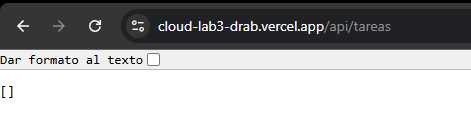

In [27]:
from IPython.display import Image, display

display(Image(filename="/content/Vercel1.png"))

## Actividad 3.3 – Proyecto Integrado: Frontend + Backend en la Nube

### Descripción

En esta actividad se integra el frontend con la API Serverless desplegada en Vercel, construyendo una aplicación distribuida completa.

El frontend permite ingresar datos de una tarea y enviarlos a la API mediante una solicitud HTTP `POST`. También permite consultar las tareas registradas mediante una solicitud `GET`. La API Serverless actúa como backend, procesando las solicitudes y devolviendo respuestas en formato JSON.

### Objetivos

- Conectar el frontend con la API Serverless.
- Implementar las operaciones de listar y crear tareas.
- Desplegar el proyecto integrado en Vercel.
- Probar el flujo completo entre frontend y backend.

In [28]:
# ================= FRONTEND INTEGRADO CON API SERVERLESS =================

html_code = """
<!DOCTYPE html>
<html lang="es">
<head>
  <meta charset="UTF-8">
  <meta name="viewport" content="width=device-width, initial-scale=1.0">
  <title>Gestión de Tareas - Laboratorio IV</title>

  <style>
    body {
      margin: 0;
      font-family: Arial, Helvetica, sans-serif;
      background: linear-gradient(135deg, #e0f2fe, #f8fafc);
      color: #1f2937;
    }

    .contenedor {
      max-width: 950px;
      margin: 50px auto;
      padding: 20px;
    }

    .tarjeta {
      background: white;
      border-radius: 18px;
      padding: 32px;
      box-shadow: 0 12px 28px rgba(0, 0, 0, 0.10);
    }

    h1 {
      text-align: center;
      color: #2563eb;
      margin-bottom: 8px;
    }

    .subtitulo {
      text-align: center;
      color: #64748b;
      margin-bottom: 30px;
    }

    .estado-api {
      background: #ecfdf5;
      color: #166534;
      border: 1px solid #bbf7d0;
      padding: 12px;
      border-radius: 10px;
      margin-bottom: 22px;
      text-align: center;
      font-size: 14px;
    }

    .formulario {
      display: grid;
      grid-template-columns: 1fr 2fr;
      gap: 14px;
      margin-bottom: 20px;
    }

    input {
      padding: 13px;
      border: 1px solid #cbd5e1;
      border-radius: 10px;
      font-size: 15px;
      outline: none;
    }

    input:focus {
      border-color: #2563eb;
      box-shadow: 0 0 0 2px rgba(37, 99, 235, 0.15);
    }

    .descripcion {
      grid-column: 1 / 3;
    }

    .botones {
      display: flex;
      gap: 12px;
      justify-content: center;
      margin-bottom: 25px;
      flex-wrap: wrap;
    }

    button {
      padding: 12px 20px;
      border: none;
      border-radius: 10px;
      font-size: 15px;
      cursor: pointer;
      font-weight: bold;
      transition: 0.2s;
    }

    .btn-crear {
      background-color: #2563eb;
      color: white;
    }

    .btn-cargar {
      background-color: #16a34a;
      color: white;
    }

    .btn-limpiar {
      background-color: #64748b;
      color: white;
    }

    button:hover {
      transform: translateY(-2px);
      opacity: 0.9;
    }

    .resultado {
      background: #f8fafc;
      border-radius: 12px;
      padding: 20px;
      min-height: 140px;
      border: 1px solid #e2e8f0;
    }

    .resultado h2 {
      margin-top: 0;
      color: #334155;
    }

    .tarea {
      background: white;
      border-left: 5px solid #2563eb;
      padding: 14px;
      margin-bottom: 12px;
      border-radius: 10px;
      box-shadow: 0 3px 8px rgba(0,0,0,0.05);
    }

    .tarea strong {
      color: #1d4ed8;
    }

    pre {
      background: #0f172a;
      color: #e5e7eb;
      padding: 15px;
      border-radius: 10px;
      overflow-x: auto;
    }

    .nota {
      font-size: 13px;
      color: #64748b;
      text-align: center;
      margin-top: 20px;
    }

    @media (max-width: 700px) {
      .formulario {
        grid-template-columns: 1fr;
      }

      .descripcion {
        grid-column: 1;
      }

      .contenedor {
        margin: 20px auto;
      }
    }
  </style>
</head>

<body>
  <div class="contenedor">
    <div class="tarjeta">
      <h1>Gestión de Tareas</h1>
      <p class="subtitulo">
        Aplicación distribuida integrada con Frontend + API Serverless en Vercel.
      </p>

      <div class="estado-api">
        API conectada: https://cloud-lab3-drab.vercel.app/api/tareas
      </div>

      <div class="formulario">
        <input id="titulo" type="text" placeholder="Título de la tarea">
        <input id="descripcion" class="descripcion" type="text" placeholder="Descripción de la tarea">
      </div>

      <div class="botones">
        <button class="btn-crear" onclick="crearTarea()">Crear Tarea</button>
        <button class="btn-cargar" onclick="cargarTareas()">Cargar Tareas</button>
        <button class="btn-limpiar" onclick="limpiarResultado()">Limpiar</button>
      </div>

      <div class="resultado">
        <h2>Resultado</h2>
        <div id="resultado">
          Aquí aparecerán las tareas obtenidas desde la API Serverless.
        </div>
      </div>

      <p class="nota">
        Laboratorio IV - Computación Paralela, Distribuida y Cloud Computing.
      </p>
    </div>
  </div>

  <script>
    const API_URL = "https://cloud-lab3-drab.vercel.app/api/tareas";

    async function crearTarea() {
      const titulo = document.getElementById("titulo").value;
      const descripcion = document.getElementById("descripcion").value;

      if (!titulo || !descripcion) {
        document.getElementById("resultado").innerHTML =
          "<p>Completa el título y la descripción antes de crear una tarea.</p>";
        return;
      }

      const tarea = {
        titulo: titulo,
        descripcion: descripcion,
        completada: false
      };

      try {
        const res = await fetch(API_URL, {
          method: "POST",
          headers: {
            "Content-Type": "application/json"
          },
          body: JSON.stringify(tarea)
        });

        const data = await res.json();

        document.getElementById("resultado").innerHTML =
          "<pre>" + JSON.stringify(data, null, 2) + "</pre>";

        document.getElementById("titulo").value = "";
        document.getElementById("descripcion").value = "";

      } catch (error) {
        document.getElementById("resultado").innerHTML =
          "<p>Error al conectar con la API Serverless.</p>";
      }
    }

    async function cargarTareas() {
      try {
        const res = await fetch(API_URL);
        const data = await res.json();

        if (data.length === 0) {
          document.getElementById("resultado").innerHTML =
            "<p>No existen tareas registradas.</p>";
          return;
        }

        let html = "";

        data.forEach(tarea => {
          html += `
            <div class="tarea">
              <p><strong>ID:</strong> ${tarea.id}</p>
              <p><strong>Título:</strong> ${tarea.titulo}</p>
              <p><strong>Descripción:</strong> ${tarea.descripcion}</p>
              <p><strong>Completada:</strong> ${tarea.completada ? "Sí" : "No"}</p>
            </div>
          `;
        });

        document.getElementById("resultado").innerHTML = html;

      } catch (error) {
        document.getElementById("resultado").innerHTML =
          "<p>No se pudo cargar la información desde la API.</p>";
      }
    }

    function limpiarResultado() {
      document.getElementById("resultado").innerHTML =
        "Aquí aparecerán las tareas obtenidas desde la API Serverless.";

      document.getElementById("titulo").value = "";
      document.getElementById("descripcion").value = "";
    }
  </script>
</body>
</html>
"""

with open("index.html", "w", encoding="utf-8") as archivo:
    archivo.write(html_code)

print("Archivo index.html integrado creado correctamente.")

Archivo index.html integrado creado correctamente.


In [29]:
from IPython.display import HTML, display

with open("index.html", "r", encoding="utf-8") as archivo:
    contenido = archivo.read()

display(HTML(contenido))

In [30]:
from google.colab import files

files.download("index.html")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Evidencias de la Actividad 3.3

Para esta actividad se incluyeron las siguientes evidencias:

- Captura del archivo `index.html` actualizado en GitHub.
- Captura del deploy exitoso en Vercel.
- Captura de la aplicación frontend funcionando.
- Captura de una tarea creada desde el frontend.
- Captura de la lista de tareas cargada desde la API Serverless.

### Análisis

En esta actividad se integró el frontend con la API Serverless desplegada en Vercel. El frontend utiliza la función `fetch()` de JavaScript para enviar solicitudes HTTP hacia el endpoint público `/api/tareas`.

La operación de crear tareas se realiza mediante el método `POST`, enviando los datos en formato JSON. La operación de listar tareas se realiza mediante el método `GET`, obteniendo la información almacenada temporalmente por la API.

Esta integración demuestra el funcionamiento de una aplicación distribuida, donde el cliente web y el backend se comunican a través de internet. El frontend se encarga de la interacción con el usuario, mientras que la API Serverless procesa las solicitudes y devuelve respuestas JSON.

# Tabla Comparativa de Tiempos – Parte I

| Actividad | Versión | Hilos | Tiempo | Speedup | Eficiencia |
|---|---|---:|---:|---:|---:|
| Búsqueda en arreglos | Secuencial | 1 | 0.0001 s | 1.0000 | 1.0000 |
| Búsqueda en arreglos | Paralela | 2 | 0.0010 s | 0.0922 | 0.0461 |
| Búsqueda en arreglos | Paralela | 4 | 0.1290 s | 0.0007 | 0.0002 |
| Búsqueda en arreglos | Paralela | 8 | 0.0017 s | 0.0519 | 0.0065 |
| Procesamiento de imágenes | Secuencial | 1 | 13.4770 s | 1.0000 | 1.0000 |
| Procesamiento de imágenes | Paralela | 2 | 12.8663 s | 1.0475 | 0.5237 |
| Procesamiento de imágenes | Paralela | 4 | 13.0058 s | 1.0362 | 0.2591 |
| Procesamiento de imágenes | Paralela | 8 | 13.0119 s | 1.0357 | 0.1295 |
| Estadísticas paralelas | Secuencial | 1 | 0.1944 s | 1.0000 | 1.0000 |
| Estadísticas paralelas | Paralela | 2 | 0.2753 s | 0.7060 | 0.3530 |
| Estadísticas paralelas | Paralela | 4 | 0.2573 s | 0.7555 | 0.1889 |
| Estadísticas paralelas | Paralela | 8 | 0.2638 s | 0.7368 | 0.0921 |

## Análisis de la tabla comparativa

En la comparación de tiempos se observa que la Actividad 1.2, correspondiente al procesamiento paralelo de imágenes, presentó el mejor speedup. Con 2 hilos obtuvo un speedup de 1.0475, lo que indica una ligera mejora frente a la versión secuencial.

En la Actividad 1.1, la búsqueda paralela no mejoró el rendimiento porque el elemento buscado apareció muy temprano en el arreglo. Por esta razón, la versión secuencial terminó rápidamente y el costo de crear y coordinar hilos fue mayor que el beneficio del paralelismo.

En la Actividad 1.3, el cálculo de estadísticas paralelas tampoco superó a la versión secuencial. Esto se debe a que las funciones internas de Python como `min`, `max` y `sum` ya están optimizadas, y el uso de hilos agrega sobrecarga adicional.

En general, los resultados muestran que el paralelismo no siempre garantiza menor tiempo de ejecución. Su efectividad depende del tamaño del problema, la independencia de las tareas, el costo de coordinación y las limitaciones del lenguaje, como el GIL en Python.

# Diagrama de Arquitectura

```text
+-------------------+
|     Usuario       |
|  Navegador Web    |
+---------+---------+
          |
          | Accede a la URL pública
          v
+-----------------------------+
| Frontend en Vercel          |
| index.html                  |
| Gestión de Tareas           |
+-------------+---------------+
              |
              | GET /api/tareas
              | POST /api/tareas
              v
+-----------------------------+
| API Serverless en Vercel    |
| api/tareas.py               |
| FastAPI                     |
+-------------+---------------+
              |
              | Respuesta JSON
              v
+-----------------------------+
| Lista de tareas en memoria  |
+-----------------------------+

+-----------------------------+
| GitHub                      |
| Repositorio cloud-lab3      |
+-------------+---------------+
              |
              | Deploy automático
              v
+-----------------------------+
| Vercel                      |
| Plataforma Cloud            |
+-----------------------------+


# Preguntas de Reflexión

## 1. ¿Qué actividad presentó mejor speedup y por qué?

La actividad que presentó mejor speedup fue el **procesamiento paralelo de imágenes**, especialmente con **2 hilos**, donde se obtuvo un speedup de **1.0475**. Esto significa que la versión paralela fue ligeramente más rápida que la versión secuencial.

Esta actividad presentó mejor speedup porque el procesamiento de imágenes puede dividirse en regiones independientes. Cada hilo puede procesar una parte de la imagen sin depender directamente del resultado de otro hilo. Sin embargo, la mejora no fue muy alta debido a las limitaciones de Python, como el GIL, y al costo de crear y coordinar hilos.

## 2. ¿Qué diferencia principal existe entre paralelismo OpenMP y distribución MPI / API?

La principal diferencia es que **OpenMP** se usa para paralelismo dentro de una misma máquina, normalmente mediante varios hilos que comparten memoria. En cambio, **MPI** y una **API** representan modelos distribuidos, donde distintos procesos, computadoras o servicios se comunican mediante mensajes o solicitudes a través de una red.

En este laboratorio, la API REST funciona como un sistema distribuido porque el frontend y el backend pueden estar separados y se comunican mediante solicitudes HTTP. El frontend envía peticiones y la API responde con datos en formato JSON.

## 3. ¿Dónde aparece la latencia en un sistema distribuido?

La latencia aparece cuando un componente del sistema necesita comunicarse con otro a través de la red. En este laboratorio, la latencia aparece cuando el frontend envía una solicitud HTTP a la API Serverless desplegada en Vercel y espera la respuesta.

También puede aparecer durante el procesamiento de la función Serverless, en el tiempo de conexión a internet, en el envío de datos desde el navegador hacia la API y en el retorno de la respuesta JSON desde el backend hacia el frontend.

## 4. ¿Qué ventajas aporta la nube frente a ejecutar todo localmente?

La nube permite publicar aplicaciones y servicios para que sean accesibles desde internet sin depender de una computadora local encendida. También facilita el despliegue automático, la disponibilidad, el acceso remoto, la escalabilidad y la administración de infraestructura.

En este laboratorio, Vercel permitió desplegar el frontend y la API Serverless sin configurar servidores manualmente. Esto demuestra una ventaja importante de la nube: el desarrollador puede enfocarse en el código mientras la plataforma administra la infraestructura, el dominio, el despliegue y la ejecución de funciones bajo demanda.

## 5. ¿Cómo escalarías este sistema para soportar miles de usuarios simultáneos?

Para escalar este sistema a miles de usuarios simultáneos, mantendría el frontend desplegado en Vercel, aprovechando su distribución global. Para el backend, usaría funciones Serverless o contenedores administrados que puedan escalar automáticamente según la cantidad de solicitudes.

También reemplazaría la lista en memoria por una base de datos real, como PostgreSQL, MongoDB, Firebase o Supabase. Además, agregaría caché, CDN, monitoreo, autenticación, límites de solicitudes y balanceo de carga para mejorar el rendimiento, la seguridad y la disponibilidad del sistema.

# Conclusión General

El Laboratorio IV permitió integrar conceptos de computación paralela, aplicaciones distribuidas y computación en la nube. En la primera parte se implementaron algoritmos paralelos para comparar tiempos de ejecución, speedup y eficiencia.

En la segunda parte se desarrolló una API REST con FastAPI y un frontend capaz de consumirla mediante solicitudes HTTP. Finalmente, se desplegó el frontend y la API en Vercel, construyendo una aplicación distribuida accesible desde internet.

La práctica permitió comprender cómo interactúan GitHub, Vercel, frontend, backend, funciones Serverless y APIs dentro de una arquitectura cloud moderna.